# Data Wrangling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import lightning as L
import os
import warnings
warnings.filterwarnings("ignore")
import gc
from PIL import Image
import glob
import json

# set random seed for reproducibility
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    L.seed_everything(seed)

set_seed(42)


KeyboardInterrupt: 

In [ ]:
flicker_df = pd.read_csv("/Users/muhammadnajmirahmani/ProjectCV/flickr_annotations_30k.csv")

In [ ]:
flicker_df
train_flickr = flicker_df[flicker_df["split"] == "train"]
val_flickr = flicker_df[flicker_df["split"] == "val"]
test_flickr = flicker_df[flicker_df["split"] == "test"]

In [ ]:
# Ubah tipe kolom raw menjadi list
train_flickr['raw'] = train_flickr['raw'].apply(lambda x: json.loads(x))
val_flickr['raw'] = val_flickr['raw'].apply(lambda x: json.loads(x))
test_flickr['raw'] = test_flickr['raw'].apply(lambda x: json.loads(x))

In [ ]:
# Keep only the first caption (index 0) from the list in 'raw' for all rows
train_flickr['raw'] = train_flickr['raw'].apply(lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) > 0 else x)
val_flickr['raw'] = val_flickr['raw'].apply(lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) > 0 else x)
test_flickr['raw'] = test_flickr['raw'].apply(lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) > 0 else x)

In [ ]:
train_flickr

,raw,sentids,split,filename,img_id
0,Two young guys with shaggy hair look at their ...,"[0, 1, 2, 3, 4]",train,1000092795.jpg,0
1,Several men in hard hats are operating a giant...,"[5, 6, 7, 8, 9]",train,10002456.jpg,1
2,A child in a pink dress is climbing up a set o...,"[10, 11, 12, 13, 14]",train,1000268201.jpg,2
3,Someone in a blue shirt and hat is standing on...,"[15, 16, 17, 18, 19]",train,1000344755.jpg,3
4,"Two men, one in a gray shirt, one in a black s...","[20, 21, 22, 23, 24]",train,1000366164.jpg,4
...,...,...,...,...,...
31009,"Woman writing on a pad in room with gold, deco...","[155045, 155046, 155047, 155048, 155049]",train,997338199.jpg,31009
31010,A person in a red shirt climbing up a rock fac...,"[155050, 155051, 155052, 155053, 155054]",train,997722733.jpg,31010
31011,Two male construction workers are working on a...,"[155055, 155056, 155057, 155058, 155059]",train,997876722.jpg,31011
31012,An older busker in glasses plays an Eastern st...,"[155060, 155061, 155062, 155063, 155064]",train,99804383.jpg,31012


In [ ]:
train_flickr.shape, val_flickr.shape, test_flickr.shape

((29000, 5), (1014, 5), (1000, 5))

In [ ]:
# Remove brackets and quotes from the captions
def clean_caption(caption):
    if isinstance(caption, str):
        return caption.strip("[]").replace("'", "").replace('"', '').strip()
    return caption

train_flickr['raw'] = train_flickr['raw'].apply(clean_caption)
val_flickr['raw'] = val_flickr['raw'].apply(clean_caption)
test_flickr['raw'] = test_flickr['raw'].apply(clean_caption)

In [ ]:
train_flickr

,raw,sentids,split,filename,img_id
0,Two young guys with shaggy hair look at their ...,"[0, 1, 2, 3, 4]",train,1000092795.jpg,0
1,Several men in hard hats are operating a giant...,"[5, 6, 7, 8, 9]",train,10002456.jpg,1
2,A child in a pink dress is climbing up a set o...,"[10, 11, 12, 13, 14]",train,1000268201.jpg,2
3,Someone in a blue shirt and hat is standing on...,"[15, 16, 17, 18, 19]",train,1000344755.jpg,3
4,"Two men, one in a gray shirt, one in a black s...","[20, 21, 22, 23, 24]",train,1000366164.jpg,4
...,...,...,...,...,...
31009,"Woman writing on a pad in room with gold, deco...","[155045, 155046, 155047, 155048, 155049]",train,997338199.jpg,31009
31010,A person in a red shirt climbing up a rock fac...,"[155050, 155051, 155052, 155053, 155054]",train,997722733.jpg,31010
31011,Two male construction workers are working on a...,"[155055, 155056, 155057, 155058, 155059]",train,997876722.jpg,31011
31012,An older busker in glasses plays an Eastern st...,"[155060, 155061, 155062, 155063, 155064]",train,99804383.jpg,31012


In [ ]:
df = pd.read_csv('/Users/muhammadnajmirahmani/ProjectCV/VizWiz_captions_project_all_metadata.csv', encoding='ISO-8859-1')
df[df['TRAIN_VAL_TEST'] == 'TEST']
# Change IMG type to string
df['IMG'] = df['IMG'].astype("string")
df['IMG'] = df['IMG'].str.split('_').str[-1]


In [ ]:
# Read train annotations
with open('/Users/muhammadnajmirahmani/ProjectCV/annotations/train.json') as f:
    train = json.load(f)

# Read test annotations
with open('/Users/muhammadnajmirahmani/ProjectCV/annotations/test.json') as f:
    test = json.load(f)

# Read val annotations
with open('/Users/muhammadnajmirahmani/ProjectCV/annotations/val.json') as f:
    val = json.load(f)

# Convert to DataFrame
train_images = pd.DataFrame(train['images'])
test_images = pd.DataFrame(test['images'])
val_images = pd.DataFrame(val['images'])

train_captions = pd.DataFrame(train['annotations'])
val_captions = pd.DataFrame(val['annotations'])

In [ ]:
test_images

,file_name,vizwiz_url,id,text_detected
0,VizWiz_test_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31181,True
1,VizWiz_test_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31182,False
2,VizWiz_test_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31183,True
3,VizWiz_test_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31184,True
4,VizWiz_test_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31185,True
...,...,...,...,...
7995,VizWiz_test_00007995.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,39176,True
7996,VizWiz_test_00007996.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,39177,True
7997,VizWiz_test_00007997.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,39178,True
7998,VizWiz_test_00007998.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,39179,True


In [ ]:
train_images

,file_name,vizwiz_url,id,text_detected
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True
1,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True
2,VizWiz_train_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,2,True
3,VizWiz_train_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,3,True
4,VizWiz_train_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,4,True
...,...,...,...,...
23426,VizWiz_train_00023426.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23426,True
23427,VizWiz_train_00023427.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23427,False
23428,VizWiz_train_00023428.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23428,True
23429,VizWiz_train_00023429.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23429,True


In [ ]:
train_captions.rename(columns={'id': 'annotation_id'}, inplace=True)
val_captions.rename(columns={'id': 'annotation_id'}, inplace=True)

Ambil 1 caption aja dari 5/4

In [ ]:
train_captions.drop_duplicates(subset=['image_id'], keep='first', inplace=True)
val_captions.drop_duplicates(subset=['image_id'], keep='first', inplace=True)
train_captions

,caption,image_id,is_precanned,is_rejected,annotation_id,text_detected
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
5,A can of Coca Cola on a counter is shown for w...,1,False,False,5,True
10,A can of crushed tomatoes are on a brown surfa...,2,False,False,10,True
15,A white screen with a captcha that needs to be...,3,False,False,15,True
20,A box for a garden light rests in someone's lap.,4,False,False,20,True
...,...,...,...,...,...,...
117130,A PlayStation 2 video game that is for the spo...,23426,False,False,117130,True
117135,A folded paper currency with a depiction of a ...,23427,False,False,117135,True
117140,A black and white sheet of paper with font let...,23428,False,False,117140,True
117145,A bottle of Healthy Hair Skin & Nails capsules.,23429,False,False,117145,True


In [ ]:
# Join images and captions for train and val by id
train_df = pd.merge(train_images, train_captions, left_on='id', right_on='image_id')
val_df = pd.merge(val_images, val_captions, left_on='id', right_on='image_id')

In [ ]:
train_df.head()

,file_name,vizwiz_url,id,text_detected_x,caption,image_id,is_precanned,is_rejected,annotation_id,text_detected_y
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
1,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True,A can of Coca Cola on a counter is shown for w...,1,False,False,5,True
2,VizWiz_train_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,2,True,A can of crushed tomatoes are on a brown surfa...,2,False,False,10,True
3,VizWiz_train_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,3,True,A white screen with a captcha that needs to be...,3,False,False,15,True
4,VizWiz_train_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,4,True,A box for a garden light rests in someone's lap.,4,False,False,20,True


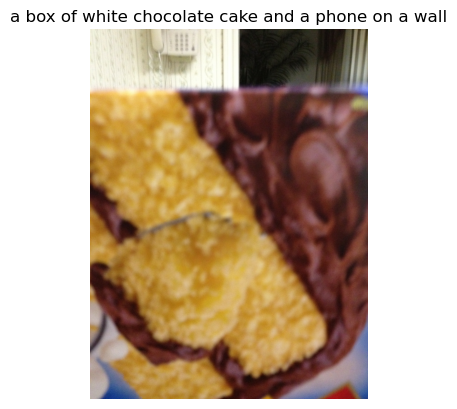

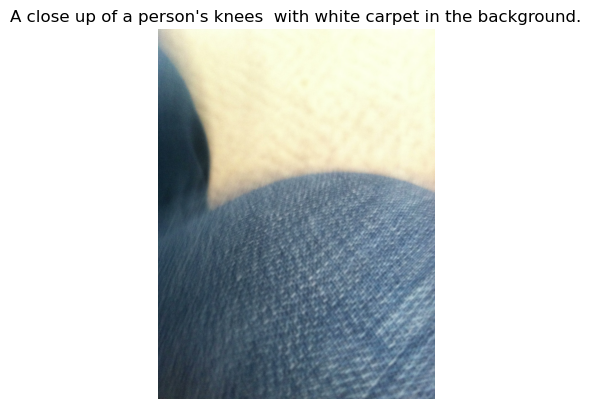

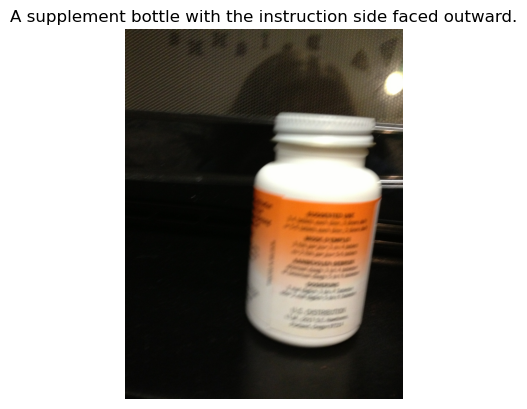

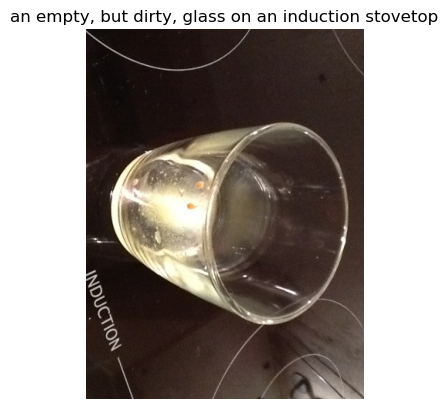

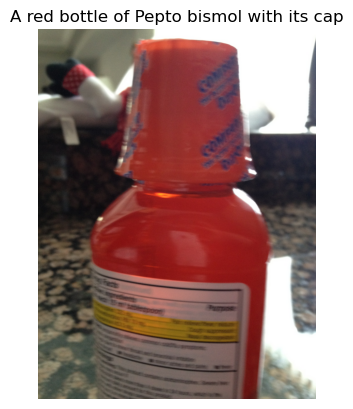

In [ ]:
# Ambil beberapa contoh gambar dan caption
sample_images = train_df.sample(5)
# Tampilkan gambar dan caption
for index, row in sample_images.iterrows():
    image_path = os.path.join('/Users/muhammadnajmirahmani/ProjectCV/train', row['file_name'])
    caption = row['caption']
    
    # Tampilkan gambar
    img = plt.imread(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption)
    plt.show()


In [ ]:
# Get size of the images from 5 random samples
sample_images = train_df.sample(5)
for index, row in sample_images.iterrows():
    image_path = os.path.join('/Users/muhammadnajmirahmani/ProjectCV/train', row['file_name'])
    img = plt.imread(image_path)
    print(f"Image: {row['file_name']}, Size: {img.shape}")

Image: VizWiz_train_00005105.jpg, Size: (1024, 768, 3)
Image: VizWiz_train_00005822.jpg, Size: (1632, 1224, 3)
Image: VizWiz_train_00019437.jpg, Size: (1632, 1224, 3)
Image: VizWiz_train_00016447.jpg, Size: (1632, 1224, 3)
Image: VizWiz_train_00010339.jpg, Size: (480, 360, 3)


In [ ]:
# Ambil image yang captionnya diterima
train_df = train_df[train_df['is_rejected'] == False]
val_df = val_df[val_df['is_rejected'] == False]
train_df

,file_name,vizwiz_url,id,text_detected_x,caption,image_id,is_precanned,is_rejected,annotation_id,text_detected_y
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
1,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True,A can of Coca Cola on a counter is shown for w...,1,False,False,5,True
2,VizWiz_train_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,2,True,A can of crushed tomatoes are on a brown surfa...,2,False,False,10,True
3,VizWiz_train_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,3,True,A white screen with a captcha that needs to be...,3,False,False,15,True
4,VizWiz_train_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,4,True,A box for a garden light rests in someone's lap.,4,False,False,20,True
...,...,...,...,...,...,...,...,...,...,...
23426,VizWiz_train_00023426.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23426,True,A PlayStation 2 video game that is for the spo...,23426,False,False,117130,True
23427,VizWiz_train_00023427.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23427,False,A folded paper currency with a depiction of a ...,23427,False,False,117135,True
23428,VizWiz_train_00023428.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23428,True,A black and white sheet of paper with font let...,23428,False,False,117140,True
23429,VizWiz_train_00023429.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23429,True,A bottle of Healthy Hair Skin & Nails capsules.,23429,False,False,117145,True


In [ ]:
flickr_root = '/Users/muhammadnajmirahmani/ProjectCV/flickr30k-images'

In [ ]:
train_img_root = '/Users/muhammadnajmirahmani/ProjectCV/train'
val_img_root = '/Users/muhammadnajmirahmani/ProjectCV/val'
test_img_root = '/Users/muhammadnajmirahmani/ProjectCV/test'

# Text Prepocessing

Preprocessing untuk image captioning

In [ ]:
# Buat preprocessing pipeline untuk text pada image caption
import re
from tkinter import END
import torch
from tokenizers import BertWordPieceTokenizer

def preprocess_caption(caption):
    # Convert to lowercase
    caption = caption.lower()
    # Remove punctuation
    caption = re.sub(r'[^\w\s]', '', caption)
    # Remove extra whitespace
    caption = re.sub(r'\s+', ' ', caption).strip()
    # Remove repeated characters (e.g., "loooove" -> "love")
    caption = re.sub(r'(.)\1{2,}', r'\1', caption)
    # Remove repeated words (e.g., "very very good" -> "very good")
    caption = re.sub(r'\b(\w+)( \1\b)+', r'\1', caption)
    return caption

train_df['processed_caption'] = train_df['caption'].apply(preprocess_caption)
val_df['processed_caption'] = val_df['caption'].apply(preprocess_caption)
train_flickr['processed_caption'] = train_flickr['raw'].apply(preprocess_caption)
val_flickr['processed_caption'] = val_flickr['raw'].apply(preprocess_caption)
test_flickr['processed_caption'] = test_flickr['raw'].apply(preprocess_caption)

# Tambahkan token khusus untuk memulai dan mengakhiri caption
train_df['processed_caption'] = '[START] ' + train_df['processed_caption'] + ' [END]'
val_df['processed_caption'] = '[START] ' + val_df['processed_caption'] + ' [END]'
train_flickr['processed_caption'] = '[START] ' + train_flickr['processed_caption'] + ' [END]'
val_flickr['processed_caption'] = '[START] ' + val_flickr['processed_caption'] + ' [END]'
test_flickr['processed_caption'] = '[START] ' + test_flickr['processed_caption'] + ' [END]'

In [ ]:
vocab_words = list(set(" ".join(train_flickr["processed_caption"]).split()))
print(len(vocab_words))

12791


In [ ]:
tokenizer = BertWordPieceTokenizer(
    unk_token="[UNK]",
    clean_text=False,
    lowercase=False
)

tokenizer.train_from_iterator(
    train_flickr["processed_caption"].tolist(),
    vocab_size=len(vocab_words) + 4,  # +4 for special tokens
    special_tokens=["[PAD]","[UNK]","[START]","[END]"]
)

In [ ]:
# Cek apakah token masuk ke dalam vocabulary
vocab = tokenizer.get_vocab()
for token in ["[PAD]", "[UNK]", "[START]", "[END]"]:
    print(f"{token}: {vocab.get(token)}")

[PAD]: 0
[UNK]: 1
[START]: 2
[END]: 3


In [ ]:
vocab = tokenizer.get_vocab()
# Encoding a sentence
example_caption = train_flickr["processed_caption"].iloc[:5]
example_tokenized_captions = tokenizer.encode_batch(example_caption)

print('caption:',example_caption[0])

for token in example_tokenized_captions[0].tokens:
    print('token:',token,"\t\tid:",vocab[token])

caption: [START] two young guys with shaggy hair look at their hands while hanging out in the yard [END]
token: [START] 		id: 2
token: two 		id: 165
token: young 		id: 191
token: guys 		id: 1458
token: with 		id: 115
token: shaggy 		id: 4031
token: hair 		id: 406
token: look 		id: 632
token: at 		id: 164
token: their 		id: 341
token: hands 		id: 530
token: while 		id: 167
token: hanging 		id: 1018
token: out 		id: 276
token: in 		id: 101
token: the 		id: 105
token: yard 		id: 1526
token: [END] 		id: 3


In [ ]:
print("[START] ID:", tokenizer.token_to_id("[START]"))
print("[END] ID:", tokenizer.token_to_id("[END]"))
print("[PAD] ID:", tokenizer.token_to_id("[PAD]"))

[START] ID: 2
[END] ID: 3
[PAD] ID: 0


In [ ]:
train_df

,file_name,vizwiz_url,id,text_detected_x,caption,image_id,is_precanned,is_rejected,annotation_id,text_detected_y,processed_caption
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True,[START] its is a basil leaves container its co...
1,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True,A can of Coca Cola on a counter is shown for w...,1,False,False,5,True,[START] a can of coca cola on a counter is sho...
2,VizWiz_train_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,2,True,A can of crushed tomatoes are on a brown surfa...,2,False,False,10,True,[START] a can of crushed tomatoes are on a bro...
3,VizWiz_train_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,3,True,A white screen with a captcha that needs to be...,3,False,False,15,True,[START] a white screen with a captcha that nee...
4,VizWiz_train_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,4,True,A box for a garden light rests in someone's lap.,4,False,False,20,True,[START] a box for a garden light rests in some...
...,...,...,...,...,...,...,...,...,...,...,...
23426,VizWiz_train_00023426.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23426,True,A PlayStation 2 video game that is for the spo...,23426,False,False,117130,True,[START] a playstation 2 video game that is for...
23427,VizWiz_train_00023427.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23427,False,A folded paper currency with a depiction of a ...,23427,False,False,117135,True,[START] a folded paper currency with a depicti...
23428,VizWiz_train_00023428.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23428,True,A black and white sheet of paper with font let...,23428,False,False,117140,True,[START] a black and white sheet of paper with ...
23429,VizWiz_train_00023429.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23429,True,A bottle of Healthy Hair Skin & Nails capsules.,23429,False,False,117145,True,[START] a bottle of healthy hair skin nails ca...


# Feature Extraction

Pakai ViT untuk extraksi fitur

In [ ]:
from transformers import ViTImageProcessor, ViTModel
import torch
import torch.nn as nn

class HuggingFaceViTEncoder(nn.Module):
    def __init__(self, model_name="google/vit-base-patch16-224-in21k"):
        super(HuggingFaceViTEncoder, self).__init__()
        # 1. Load Processor (untuk resize & normalisasi otomatis)
        self.processor = ViTImageProcessor.from_pretrained(model_name)
        
        # 2. Load Model (Tanpa head klasifikasi)
        self.model = ViTModel.from_pretrained(model_name)
        
        # 3. Freeze parameter (opsional di awal training)
        for param in self.model.parameters():
            param.requires_grad = False

    def forward(self, images):
        """
        images: tensor dari dataloader (batch, 3, 224, 224)
        """
        # Jalankan melalui model ViT
        outputs = self.model(pixel_values=images)
        
        # 'last_hidden_state' berisi fitur dari semua patch
        # Shape: (batch_size, 197, 768)
        # 197 berasal dari 1 CLS token + 196 patches (14x14)
        last_hidden_state = outputs.last_hidden_state
        
        # Kita ambil HANYA patch features (indeks 1 sampai akhir)
        # (batch, 196, 768)
        patch_features = last_hidden_state[:, 1:, :]
        
        return patch_features
    
# Extract features untuk 5 gambar sampel
sample_images = train_df.sample(5)
encoder = HuggingFaceViTEncoder()
for index, row in sample_images.iterrows():
    image_path = os.path.join(train_img_root, row['file_name'])
    img = plt.imread(image_path)
    # Preprocess gambar menggunakan processor
    inputs = encoder.processor(images=img, return_tensors="pt")
    pixel_values = inputs['pixel_values']  # Shape: (1, 3, 224, 224)
    # Extract fitur patch
    with torch.no_grad():
        patch_features = encoder(pixel_values)  # Shape: (1, 196, 768) 768 dimensi embedding
    print(f"Image: {row['file_name']}, Patch Features Shape: {patch_features.shape}")
    

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Image: VizWiz_train_00001071.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00010682.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00005349.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00013298.jpg, Patch Features Shape: torch.Size([1, 196, 768])
Image: VizWiz_train_00017892.jpg, Patch Features Shape: torch.Size([1, 196, 768])


In [ ]:
# Image.open(image_path).convert("RGB")

In [ ]:
train_images

,file_name,vizwiz_url,id,text_detected
0,VizWiz_train_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,0,True
1,VizWiz_train_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,1,True
2,VizWiz_train_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,2,True
3,VizWiz_train_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,3,True
4,VizWiz_train_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,4,True
...,...,...,...,...
23426,VizWiz_train_00023426.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23426,True
23427,VizWiz_train_00023427.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23427,False
23428,VizWiz_train_00023428.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23428,True
23429,VizWiz_train_00023429.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23429,True


In [ ]:
train_captions

,caption,image_id,is_precanned,is_rejected,annotation_id,text_detected
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True
5,A can of Coca Cola on a counter is shown for w...,1,False,False,5,True
10,A can of crushed tomatoes are on a brown surfa...,2,False,False,10,True
15,A white screen with a captcha that needs to be...,3,False,False,15,True
20,A box for a garden light rests in someone's lap.,4,False,False,20,True
...,...,...,...,...,...,...
117130,A PlayStation 2 video game that is for the spo...,23426,False,False,117130,True
117135,A folded paper currency with a depiction of a ...,23427,False,False,117135,True
117140,A black and white sheet of paper with font let...,23428,False,False,117140,True
117145,A bottle of Healthy Hair Skin & Nails capsules.,23429,False,False,117145,True


In [ ]:
# import pickle

# images = []
# sample_images = train_df.sample(min(512, len(train_df)), random_state=42).reset_index(drop=True)

# for index, row in train_images.iterrows():
#     image_path = os.path.join(train_img_root, row['file_name'])
#     img = Image.open(image_path).convert("RGB")
#     img = encoder.processor(images=img, return_tensors="pt")['pixel_values'].squeeze(0)  # Shape: (3, 224, 224)
#     images.append(img)

In [ ]:
# with open('sample_images.pkl', 'wb') as f:
#     pickle.dump(images, f)

In [ ]:
pixel_values

tensor([[[[-0.5373, -0.4902, -0.3804,  ...,  0.1608,  0.0980,  0.0667],
          [-0.4588, -0.5059, -0.4039,  ...,  0.1216,  0.0980,  0.1373],
          [-0.4275, -0.4902, -0.4039,  ...,  0.1765,  0.1686,  0.2078],
          ...,
          [-0.5843, -0.5451, -0.4588,  ...,  0.6863,  0.6706,  0.7020],
          [-0.5294, -0.5529, -0.4745,  ...,  0.6863,  0.6863,  0.7020],
          [-0.4980, -0.5216, -0.4902,  ...,  0.7098,  0.7412,  0.6941]],

         [[-0.6471, -0.6000, -0.5137,  ...,  0.0980,  0.0275,  0.0039],
          [-0.6471, -0.6549, -0.5216,  ...,  0.0353,  0.0118,  0.0353],
          [-0.6549, -0.6549, -0.5216,  ...,  0.1059,  0.0745,  0.0980],
          ...,
          [-0.6863, -0.6627, -0.6000,  ..., -0.0196, -0.0275,  0.0196],
          [-0.6784, -0.6784, -0.5922,  ..., -0.0510, -0.0196,  0.0196],
          [-0.6706, -0.6314, -0.5686,  ..., -0.0510, -0.0118,  0.0118]],

         [[-0.8588, -0.8353, -0.7804,  ..., -0.0039, -0.0353, -0.0275],
          [-0.8824, -0.8824, -

In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# Pastikan processor tersedia dari model ViT yang sama
vit_model_name = "google/vit-base-patch16-224-in21k"
vit_processor = ViTImageProcessor.from_pretrained(vit_model_name)

# Penting: reset index setelah filtering agar indexing Dataset aman
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

class CaptionDataset(Dataset):
    def __init__(self, df, img_root, processor, vocab):
        self.df = df
        self.img_root = img_root
        self.processor = processor
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.img_root, row["file_name"])

        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        # Turn into tensor of token ids
        caption_ids = torch.tensor(tokenizer.encode(row["processed_caption"]).ids, dtype=torch.long)
        return pixel_values, caption_ids

class CaptionDatasetFlickr(Dataset):
    def __init__(self, df, img_root, processor, vocab):
        self.df = df
        self.img_root = img_root
        self.processor = processor
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.img_root, row["filename"])

        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        # Turn into tensor of token ids
        caption_ids = torch.tensor(tokenizer.encode(row["processed_caption"]).ids, dtype=torch.long)
        return pixel_values, caption_ids

from torch.nn.utils.rnn import pad_sequence

def caption_collate_fn(batch):
    pixel_values, captions = zip(*batch)
    pixel_values = torch.stack(pixel_values, dim=0)
    captions = pad_sequence(captions, batch_first=True, padding_value=tokenizer.token_to_id("[PAD]"))
    return pixel_values, captions

# Supaya cepat untuk belajar awal, pakai subset kecil dulu
train_subset = train_df.sample(min(512, len(train_df)), random_state=42).reset_index(drop=True)
val_subset = val_df.sample(min(128, len(val_df)), random_state=42).reset_index(drop=True)

train_flickr_dataset = CaptionDatasetFlickr(train_flickr, flickr_root, vit_processor, vocab)
val_flickr_dataset = CaptionDatasetFlickr(val_flickr, flickr_root, vit_processor, vocab)
test_flickr_dataset = CaptionDatasetFlickr(test_flickr, flickr_root, vit_processor, vocab)

train_dataset = CaptionDataset(train_df, train_img_root, vit_processor, vocab)
val_dataset = CaptionDataset(val_df, val_img_root, vit_processor, vocab)

train_loader = DataLoader(train_dataset, 
                          batch_size=64, 
                          shuffle=True, 
                          num_workers=0, 
                          collate_fn=caption_collate_fn, 
                          pin_memory=True
                          )
val_loader = DataLoader(val_dataset, 
                        batch_size=64, 
                        shuffle=False, 
                        num_workers=0, 
                        collate_fn=caption_collate_fn,
                        pin_memory=True
                        )

train_flickr_loader = DataLoader(train_flickr_dataset, 
                          batch_size=64, 
                          shuffle=True, 
                          num_workers=0, 
                          collate_fn=caption_collate_fn,
                          pin_memory=True
                          )
val_flickr_loader = DataLoader(val_flickr_dataset, 
                        batch_size=64, 
                        shuffle=False, 
                        num_workers=0, 
                        collate_fn=caption_collate_fn,
                        pin_memory=True
                        )
test_flickr_loader = DataLoader(test_flickr_dataset, 
                        batch_size=64, 
                        shuffle=False, 
                        num_workers=0, 
                        collate_fn=caption_collate_fn,
                        pin_memory=True
                        )

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 22748, Val samples: 7502


In [ ]:
# # Get caption ids untuk batch pertama
# for batch in train_loader:
#     pixel_values, caption_ids = batch
#     print("Pixel Values Shape:", pixel_values.shape)  # (batch_size, 3, 224, 224)
#     print("Caption IDs Shape:", caption_ids.shape)    # (batch_size, max_caption_length)
#     print("Caption IDs:", caption_ids[0])  # Lihat token ids untuk caption pertama di batch
#     break

In [ ]:
# Word embedding dengan Word2Vec atau GloVe bisa dilakukan di sini, tapi untuk model captioning biasanya kita langsung belajar embedding dari awal (randomly initialized) karena kita ingin model belajar representasi yang optimal untuk tugas captioning. Namun, jika kamu ingin mencoba pre-trained embeddings, kamu bisa menggunakan library seperti Gensim untuk memuat Word2Vec atau GloVe dan membuat matriks embedding yang sesuai dengan vocabulary yang sudah dibuat.

In [ ]:
import torch.nn.functional as F
import math

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
        x = self.dropout(F.relu(self.linear1(x)))
        x = self.linear2(x)
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].detach()
        return self.dropout(x)

class LSTMWithCrossAttentionDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_idx,
        embed_dim=256,
        hidden_dim=512,
        encoder_dim=768,
        num_layers=1,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Query dim = hidden_dim, Key/Value dim = encoder_dim
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            kdim=encoder_dim,
            vdim=encoder_dim,
            dropout=dropout,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, captions_in, encoder_features):
        # captions_in: (B, T), encoder_features: (B, N, encoder_dim)
        emb = self.embedding(captions_in)              # (B, T, E)
        lstm_out, _ = self.lstm(emb)                   # (B, T, H)

        attn_out, attn_weights = self.cross_attn(
            query=lstm_out,
            key=encoder_features,
            value=encoder_features,
            need_weights=True,
        )                                               # (B, T, H)

        # Residual + norm setelah attention
        attn_out = self.norm(lstm_out + attn_out)

        fused = torch.cat([lstm_out, attn_out], dim=-1)
        logits = self.fc(self.dropout(fused))          # (B, T, vocab_size)
        return logits, attn_weights

class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, encoder_dim=768, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            kdim=encoder_dim,
            vdim=encoder_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.ffn = FeedForward(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x, enc_output, src_mask, tgt_mask):
        # Self attention 
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Cross attention (k, v dari encoder)
        attn_output, _ = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        
        # Feed forward
        ffn_output = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_output))
        return x

class ViTImageCaptioner(nn.Module):
    def __init__(self, model_name, vocab_size, pad_idx, d_model, freeze_encoder=True):
        super().__init__()
        self.encoder = ViTModel.from_pretrained(model_name)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1)

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx) # Embedding untuk input caption
        self.decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=8, batch_first=True, dropout=0.1)
        self.decoder = nn.TransformerDecoder(self.decoder_layer, num_layers=3)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, pixel_values, captions_in):
        tgt_mask = self.generate_square_subsequent_mask(captions_in.size(1)).to(captions_in.device)
        encoder_out = self.encoder(pixel_values=pixel_values).last_hidden_state
        patch_features = encoder_out[:, 1:, :]  # buang CLS token (1, 196, 768)
        
        # Embed input caption
        embedded_captions = self.embedding(captions_in)  # (B, T, d_model)

        # Positional encoding
        embedded_captions = self.positional_encoding(embedded_captions)

        # Decode dengan cross attention k, v dari patch features
        decoder_output = self.decoder(embedded_captions, patch_features, tgt_mask=tgt_mask)  # (B, T, d_model)
        logits = self.fc_out(decoder_output)  # (B, T, vocab_size)
        return logits, None  # Untuk attn_weights set None dulu
    
    def generate_square_subsequent_mask(self, sz):
            mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
            mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
            return mask
        

class ViTLSTMCaptioner(nn.Module):
    def __init__(self, model_name, vocab_size, pad_idx, freeze_encoder=True):
        super().__init__()
        self.encoder = ViTModel.from_pretrained(model_name)

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.decoder = LSTMWithCrossAttentionDecoder(
            vocab_size=vocab_size,
            pad_idx=pad_idx,
            embed_dim=256,
            hidden_dim=512,
            encoder_dim=self.encoder.config.hidden_size,
            num_layers=1,
            num_heads=8,
            dropout=0.1,
        )

    def forward(self, pixel_values, captions_in):
        encoder_out = self.encoder(pixel_values=pixel_values).last_hidden_state
        patch_features = encoder_out[:, 1:, :]  # buang CLS token
        logits, attn_weights = self.decoder(captions_in, patch_features)
        return logits, attn_weights

class LightningCaptionModel(L.LightningModule):
    def __init__(self, model, lr=1e-4):
        super().__init__()
        self.model = model
        self.lr = lr
        self.criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id("[PAD]"))

    def forward(self, pixel_values, captions_in):
        return self.model(pixel_values, captions_in)
    
    def training_step(self, batch, batch_idx):
        pixel_values, captions = batch
        captions_in = captions[:, :-1]  # Input ke decoder (tanpa token END)
        captions_out = captions[:, 1:]   # Target output (tanpa token START)
        
        logits, _ = self(pixel_values, captions_in)
        loss = self.criterion(
            logits.reshape(-1, logits.size(-1)),
            captions_out.reshape(-1),
        )
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        pixel_values, captions = batch
        captions_in = captions[:, :-1]
        captions_out = captions[:, 1:]
        
        logits, _ = self(pixel_values, captions_in)
        loss = self.criterion(logits.reshape(-1, logits.size(-1)), captions_out.reshape(-1))
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2
        )
        return {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "val_loss"}
    
    def generate_caption(self, pixel_values, max_length=20):
        self.eval()
        with torch.no_grad():
            encoder_out = self.model.encoder(pixel_values=pixel_values).last_hidden_state
            patch_features = encoder_out[:, 1:, :]
            generated_ids = [tokenizer.token_to_id("[START]")]

            for _ in range(max_length):
                captions_in = torch.tensor(generated_ids).unsqueeze(0).to(pixel_values.device)
                
                # Saat inference (generate per kata), kita tidak butuh tgt_mask
                # karena tidak ada kata masa depan yang bisa dicontek
                embedded_captions = self.model.embedding(captions_in)
                x = self.model.positional_encoding(embedded_captions)
                
                for layer in self.model.decoder_layers:
                    x = layer(x, patch_features, src_mask=None, tgt_mask=None)
                    
                logits = self.model.fc_out(x)
                
                # Ambil logits dari kata terakhir
                next_token_logits = logits[0, -1, :]
                
                # kasih penalty untuk token yang sudah muncul supaya model lebih kreatif
                repetition_penalty = 1.2
                for token_id in set(generated_ids):
                    if next_token_logits[token_id] < 0:
                        next_token_logits[token_id] *= repetition_penalty
                    else:
                        next_token_logits[token_id] /= repetition_penalty

                next_token_id = next_token_logits.argmax(dim=-1).item()
                generated_ids.append(next_token_id)

                if next_token_id == tokenizer.token_to_id("[END]"):
                    break

        return tokenizer.decode(generated_ids)
    
device = "mps" if torch.backends.mps.is_available() else "cpu"
pad_idx = tokenizer.token_to_id("[PAD]")
model = LightningCaptionModel(
    model=ViTImageCaptioner(
        model_name="google/vit-base-patch16-224-in21k",
        vocab_size=tokenizer.get_vocab_size(),
        pad_idx=pad_idx,
        d_model=768,
        freeze_encoder=True,
    ).to(device)
)
# model = torch.compile(model)
print(f"Device: {device}")
print(f"Jumlah parameter trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Device: mps
Jumlah parameter trainable: 49,746,520


# Train lightning

In [ ]:
%%time
from lightning.pytorch.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor="val_loss", patience=3, mode="min", verbose=True, min_delta=0.001)

trainer = L.Trainer(
    max_epochs=30,
    accelerator=device,
    devices=1 if device != "cpu" else None,
    log_every_n_steps=50,
    callbacks=[early_stopping]
)

trainer.fit(model, train_flickr_loader, val_flickr_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ViTImageCaptioner │  136 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 49.7 M                                                                                           
Non-trainable params: 86.4 M                                                                                       
Total params: 136 M                                                                                                
Total estimated model params size (MB): 544                                                                        
Modules in train mode: 64                                                                                          
Modules in eval mode: 215                                                                                          
Total FLOPs: 0

Output()

In [ ]:
# Evaluate the model on a few samples from the validation set and also the images
model = model.to(device)
model.eval()
for i in range(50):
    pixel_values, captions = val_dataset[i]
    pixel_values = pixel_values.unsqueeze(0).to(device)  # (1, 3, 224, 224)
    generated_caption = model.generate_caption(pixel_values)
    img = pixel_values.squeeze(0).cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Generated: {generated_caption}\nGround Truth: {tokenizer.decode(captions.cpu().numpy())}")
    plt.show()
    # print(f"Generated Caption: {generated_caption}")
    # print(f"Ground Truth Caption: {tokenizer.decode(captions.cpu().numpy())}")
    # print("-" * 50)

In [ ]:
# Save the model
torch.save(model.state_dict(), "vit_captioner.pth")

# Save in h5 format
torch.save(model.state_dict(), "vit_captioner.h5")

In [ ]:
train_flickr['processed_caption'] = train_flickr['raw'].apply(preprocess_caption)
val_flickr['processed_caption'] = val_flickr['raw'].apply(preprocess_caption)
test_flickr['processed_caption'] = test_flickr['raw'].apply(preprocess_caption)

In [ ]:
train_flickr

In [ ]:
flickr_root = '/Users/muhammadnajmirahmani/ProjectCV/flickr30k-images'

train_flickr_dataset = CaptionDatasetFlickr(train_flickr, flickr_root, vit_processor, vocab)
val_flickr_dataset = CaptionDatasetFlickr(val_flickr, flickr_root, vit_processor, vocab)
test_flickr_dataset = CaptionDatasetFlickr(test_flickr, flickr_root, vit_processor, vocab)

In [ ]:
# Evaluate the model on a few samples from the validation set and also the images of flickr dataset
model = model.to(device)
model.eval()
for i in range(50):
    pixel_values, captions = val_flickr_dataset[i]
    pixel_values = pixel_values.unsqueeze(0).to(device)  # (1, 3, 224, 224)
    generated_caption = model.generate_caption(pixel_values)
    img = pixel_values.squeeze(0).cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Generated: {generated_caption}\nGround Truth: {tokenizer.decode(captions.cpu().numpy())}")
    plt.show()
    # print(f"Generated Caption: {generated_caption}")
    # print(f"Ground Truth Caption: {tokenizer.decode(captions.cpu().numpy())}")
    # print("-" * 50)

In [ ]:
# Import model
saved_model = torch.load("vit_captioner.pth")

In [ ]:
from tqdm.notebook import tqdm

# # Full dataset (semua data)
# train_dataset = CaptionDataset(train_df, train_img_root, vit_processor, vocab)
# val_dataset = CaptionDataset(val_df, val_img_root, vit_processor, vocab)

# batch_size = 32

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=0,
#     collate_fn=caption_collate_fn,
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=batch_size,
#     shuffle=False,
#     num_workers=0,
#     collate_fn=caption_collate_fn,
# )

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
)

# Scheduler: turunkan LR jika val loss stagnan
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

num_epochs = 4
best_val_loss = float("inf")
early_stopping_patience = 3
epochs_no_improve = 0

# Set ke None kalau mau full training
max_train_batches = None
max_val_batches = None

history = {"train_loss": [], "val_loss": [], "lr": []}

for epoch in range(num_epochs):
    # ---- Train ----
    model.train()
    train_loss_sum = 0.0
    train_steps = 0

    train_pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}", leave=False)
    for batch_idx, (pixel_values, captions) in enumerate(train_pbar):
        if max_train_batches is not None and batch_idx >= max_train_batches:
            break

        pixel_values = pixel_values.to(device)
        captions = captions.to(device)

        captions_in = captions[:, :-1]
        captions_target = captions[:, 1:]

        optimizer.zero_grad()
        logits, _ = model(pixel_values, captions_in)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            captions_target.reshape(-1),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item()
        train_steps += 1
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss_sum / max(train_steps, 1)

    # ---- Validation ----
    model.eval()
    val_loss_sum = 0.0
    val_steps = 0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{num_epochs}", leave=False)
        for batch_idx, (pixel_values, captions) in enumerate(val_pbar):
            if max_val_batches is not None and batch_idx >= max_val_batches:
                break

            pixel_values = pixel_values.to(device)
            captions = captions.to(device)

            captions_in = captions[:, :-1]
            captions_target = captions[:, 1:]

            logits, _ = model(pixel_values, captions_in)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                captions_target.reshape(-1),
            )

            val_loss_sum += loss.item()
            val_steps += 1
            val_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_val_loss = val_loss_sum / max(val_steps, 1)

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # Simpan model terbaik
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_loss": best_val_loss,
            },
            "best_vit_lstm_captioner.pth",
        )
        print("Best model saved.")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print("Early stopping triggered.")
        break

print("Training selesai.")

In [ ]:
# Visualisasi kurva training
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Skema training image captioning (ViT + Transformer Decoder Layer)

training_schema = {
    "1) Input": "Batch dari train_loader -> (pixel_values, captions)",
    "2) Teacher Forcing": "captions_in = captions[:, :-1], target = captions[:, 1:]",
    "3) Forward": "pixel_values -> ViT encoder -> patch features -> token embedding + positional encoding -> Transformer decoder layer (self-attn + cross-attn + FFN) -> logits",
    "4) Loss": "CrossEntropyLoss(logits vs target, ignore_index=[PAD])",
    "5) Backprop": "zero_grad -> backward -> gradient clipping -> optimizer.step()",
    "6) Validation": "Hitung val loss tanpa gradient",
    "7) Scheduler": "ReduceLROnPlateau berdasarkan val loss",
    "8) Checkpoint": "Simpan model terbaik jika val loss membaik",
    "9) Early Stopping": "Stop jika tidak ada perbaikan selama beberapa epoch",
}

print("=== SKEMA TRAINING IMAGE CAPTIONING (ViT + Transformer Decoder) ===")
for k, v in training_schema.items():
    print(f"{k}\n   {v}")

# Verifikasi shape dari 1 batch
pixel_values, captions = next(iter(train_loader))
pixel_values = pixel_values.to(device)
captions = captions.to(device)

captions_in = captions[:, :-1]
captions_target = captions[:, 1:]

with torch.no_grad():
    logits, _ = model(pixel_values, captions_in)

print("\n=== VERIFIKASI SHAPE ===")
print("pixel_values      :", tuple(pixel_values.shape))      # (B, 3, 224, 224)
print("captions          :", tuple(captions.shape))          # (B, T)
print("captions_in       :", tuple(captions_in.shape))       # (B, T-1)
print("captions_target   :", tuple(captions_target.shape))   # (B, T-1)
print("logits            :", tuple(logits.shape))            # (B, T-1, vocab_size)

print("\n=== PENJELASAN SINGKAT ===")
print(
    "Model dilatih dengan teacher forcing: prediksi token ke-t menggunakan urutan token input.\n"
    "ViT mengekstrak fitur patch gambar, lalu Transformer decoder memproses caption embedding\n"
    "dan melakukan cross-attention ke fitur gambar untuk menghasilkan logits kata.\n"
    "Loss mengabaikan [PAD], parameter di-update dengan AdamW, lalu divalidasi tiap epoch.\n"
    "Scheduler LR, checkpoint terbaik, dan early stopping dipakai agar training stabil."
)